In [76]:
import pandas as pd
df = pd.read_csv('/Users/anaghanair/Downloads/youtube-pipeline/data/youtube_clean.csv')

In [77]:
df.head()

,video_id,title,published_at,channel_title,view_count,like_count,comment_count,tags,duration_parsed,time_bucket,is_weekend,engagement_rate,views_per_day,tag_count
0,SixTbTc6YCg,"ice spice, tokischa - thootie",2025-12-05 17:00:06+00:00,IceSpiceVEVO,507592,48110,2640,"['Ice Spice', 'Tokischa', '10K Projects/Capito...",2.550,Afternoon,0,9.478085,507592.0,4
1,VI6XO8EijT4,digital circus ep 7 trailer!!,2025-12-05 20:00:28+00:00,GLITCH,4197858,429563,25393,"['glitch', 'glitch productions', 'digital circ...",0.967,Evening,0,10.232909,4197858.0,19
2,eWPZLDvRebU,5000 days - [hardcore minecraft],2025-12-05 23:00:54+00:00,Luke TheNotable,623223,46790,5437,"['luke thenotable', 'Minecraft', '100 Days', '...",120.017,Night,0,7.507746,623223.0,19
3,FeaRXx2VDhI,top 50 christmas songs of all time 🎄 best chri...,2025-12-05 11:30:23+00:00,Christmas Songs and Carols - Love to Sing,550238,2143,121,"['top christmas song', 'christmas songs', 'top...",139.183,Morning,0,0.389468,550238.0,14
4,IaEtA56pd_w,iron lung: final trailer,2025-12-05 20:48:18+00:00,Markiplier,2067888,322919,16749,"['markiplier', 'iron lung', 'iron lung movie',...",1.750,Evening,0,15.615884,2067888.0,11


In [78]:
df.describe() 

,view_count,like_count,comment_count,duration_parsed,is_weekend,engagement_rate,views_per_day,tag_count
count,5.000000e+01,50.000000,50.000000,50.000000,50.000000,50.000000,5.000000e+01,50.000000
mean,7.266259e+05,48100.060000,3806.120000,46.756720,0.220000,6.310544,6.962868e+05,13.420000
std,1.037126e+06,82665.537292,5758.145835,103.956027,0.418452,3.331498,1.032006e+06,10.730635
min,2.495700e+04,778.000000,1.000000,0.967000,0.000000,0.389468,2.495700e+04,1.000000
25%,1.514312e+05,6795.500000,395.750000,2.983000,0.000000,3.990766,1.514312e+05,3.000000
50%,4.250680e+05,19589.500000,1190.500000,6.283500,0.000000,6.095561,3.690880e+05,13.000000
75%,7.134250e+05,46308.000000,4529.250000,26.783500,0.000000,8.266430,6.662000e+05,21.750000
max,5.529054e+06,429563.000000,25393.000000,512.700000,1.000000,15.615884,5.529054e+06,40.000000


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   video_id         50 non-null     object 
 1   title            50 non-null     object 
 2   published_at     50 non-null     object 
 3   channel_title    50 non-null     object 
 4   view_count       50 non-null     int64  
 5   like_count       50 non-null     int64  
 6   comment_count    50 non-null     int64  
 7   tags             50 non-null     object 
 8   duration_parsed  50 non-null     float64
 9   time_bucket      50 non-null     object 
 10  is_weekend       50 non-null     int64  
 11  engagement_rate  50 non-null     float64
 12  views_per_day    50 non-null     float64
 13  tag_count        50 non-null     int64  
dtypes: float64(3), int64(5), object(6)
memory usage: 5.6+ KB


In [80]:
df.isna().sum()

video_id           0
title              0
published_at       0
channel_title      0
view_count         0
like_count         0
comment_count      0
tags               0
duration_parsed    0
time_bucket        0
is_weekend         0
engagement_rate    0
views_per_day      0
tag_count          0
dtype: int64

In [81]:
df.nunique()

video_id           50
title              50
published_at       50
channel_title      50
view_count         50
like_count         50
comment_count      49
tags               43
duration_parsed    48
time_bucket         5
is_weekend          2
engagement_rate    50
views_per_day      50
tag_count          27
dtype: int64

In [82]:
import matplotlib.pyplot as plt
import numpy as np

In [83]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

num_cols, cat_cols


(Index(['view_count', 'like_count', 'comment_count', 'duration_parsed',
        'is_weekend', 'engagement_rate', 'views_per_day', 'tag_count'],
       dtype='object'),
 Index(['video_id', 'title', 'published_at', 'channel_title', 'tags',
        'time_bucket'],
       dtype='object'))

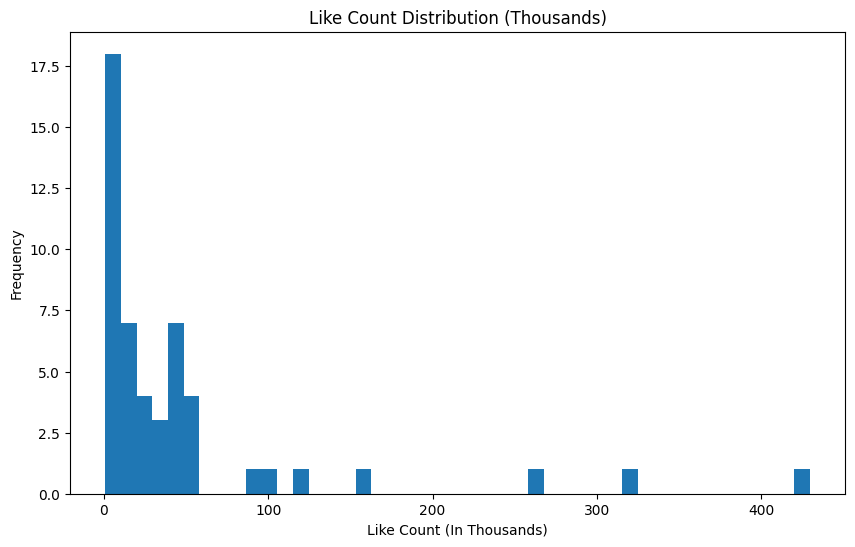

In [84]:
df['like_count_k'] = df['like_count']/1000
df['like_count_k'].plot(kind='hist', bins=45, figsize=(10,6))
plt.title('Like Count Distribution (Thousands)')
plt.xlabel('Like Count (In Thousands)')
plt.ylabel('Frequency')
plt.show()

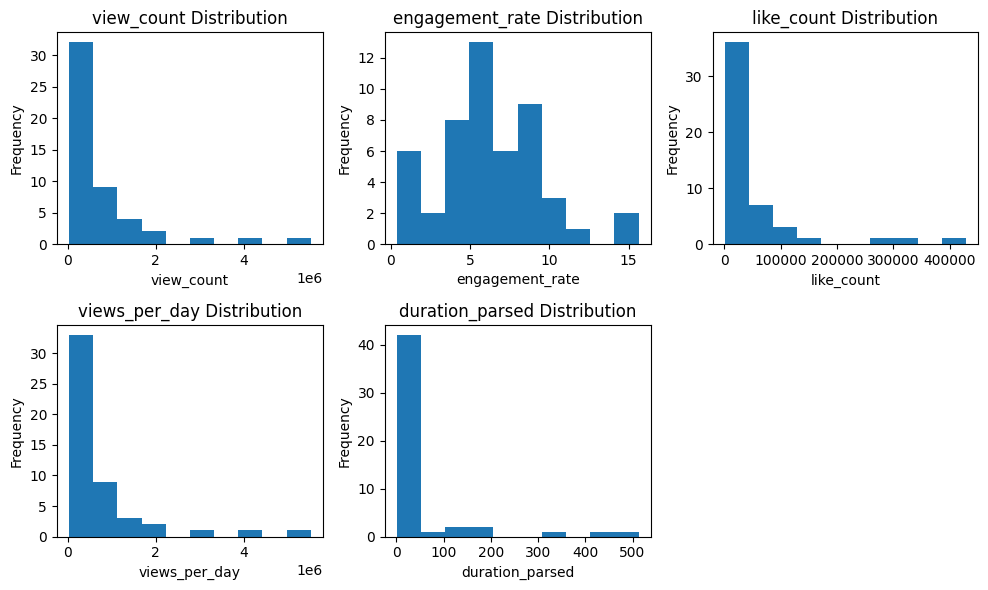

In [85]:
plt.figure(figsize=(10,6))
columns_to_plot = ['view_count', 'engagement_rate', 'like_count', 'views_per_day', 'duration_parsed']
for i,col in enumerate(columns_to_plot,1):
    plt.subplot(2,3,i)
    df[col].plot(kind='hist',bins=10)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()



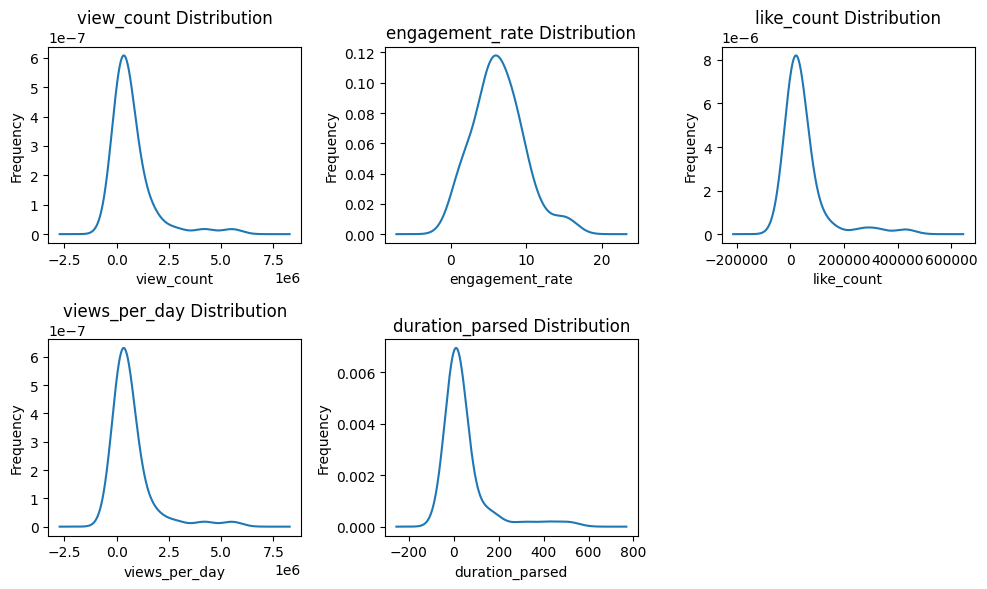

In [86]:
plt.figure(figsize=(10,6))

for i,col in enumerate(columns_to_plot,1):
    plt.subplot(2,3,i)
    df[col].plot(kind='kde')
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()



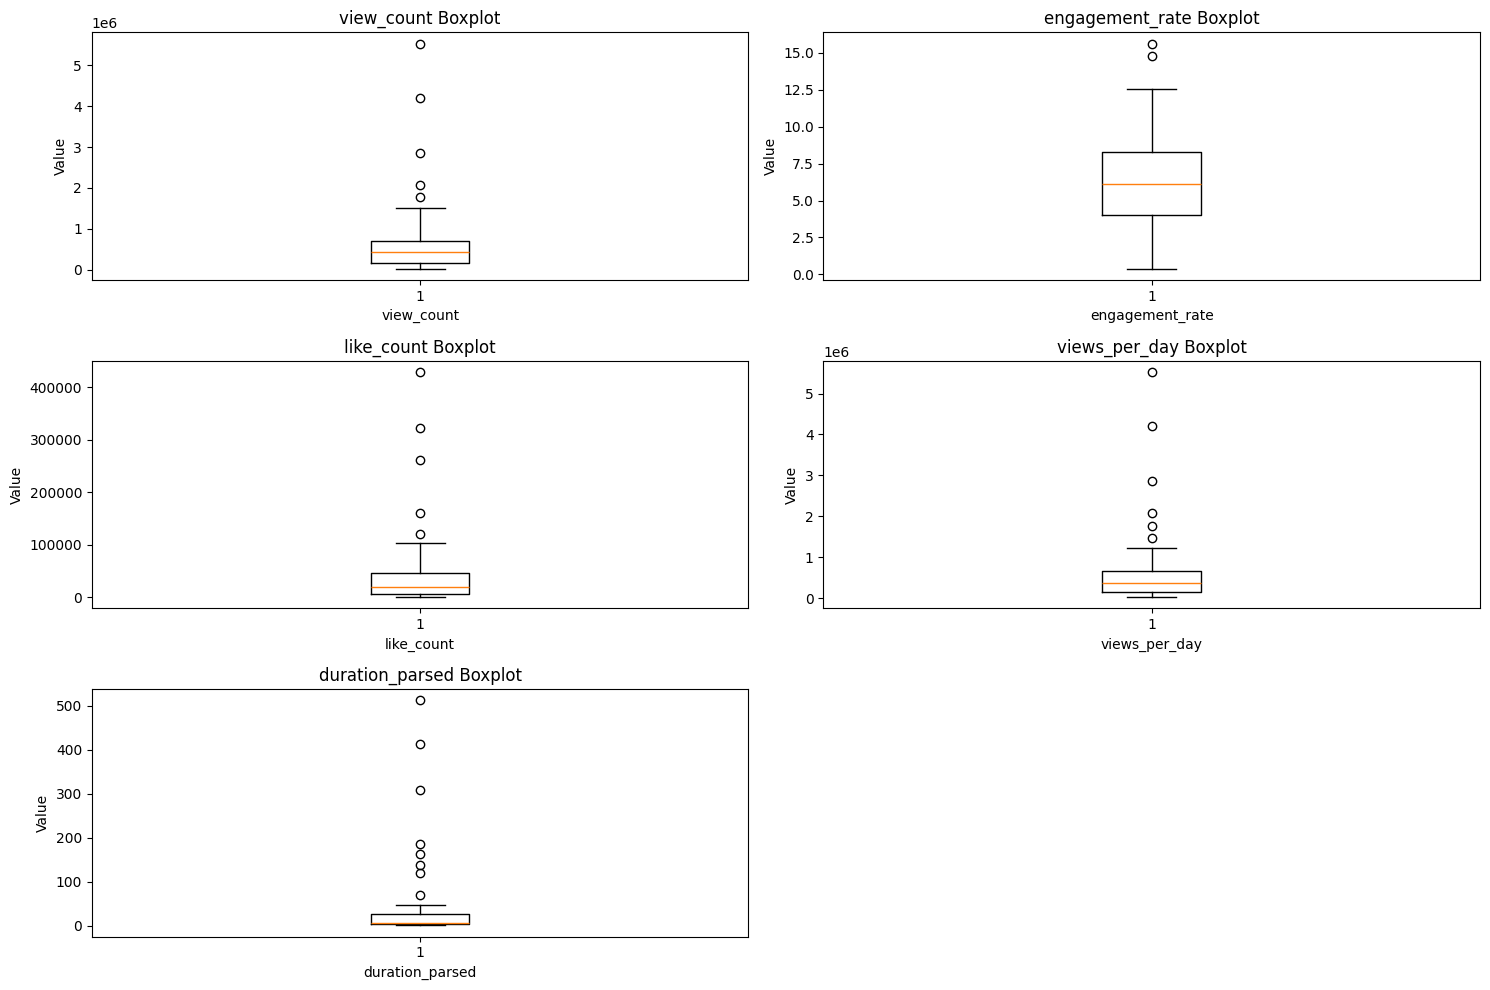

In [87]:
fig = plt.figure(figsize=(15,10))
for i,col in enumerate(columns_to_plot,1):
    ax = fig.add_subplot(3,2,i)
    ax.boxplot(df[col])
    ax.set_title(f"{col} Boxplot")
    ax.set_xlabel(col)
    ax.set_ylabel('Value')
plt.tight_layout()
plt.show()

In [88]:
df.groupby('time_bucket')['view_count'].mean().sort_values(ascending=False)

time_bucket
Evening       1.826629e+06
Night         7.601843e+05
Afternoon     6.669429e+05
Morning       3.620126e+05
Late Night    2.140521e+05
Name: view_count, dtype: float64

In [89]:
df.groupby('time_bucket')['engagement_rate'].mean().sort_values(ascending=False)

time_bucket
Evening       7.660246
Late Night    6.508237
Night         6.459934
Afternoon     6.027570
Morning       3.957623
Name: engagement_rate, dtype: float64

In [90]:
df.groupby('time_bucket')['duration_parsed'].mean().sort_values(ascending=False)

time_bucket
Morning       175.146400
Afternoon      44.095917
Late Night     34.228231
Night          29.798750
Evening        16.300125
Name: duration_parsed, dtype: float64

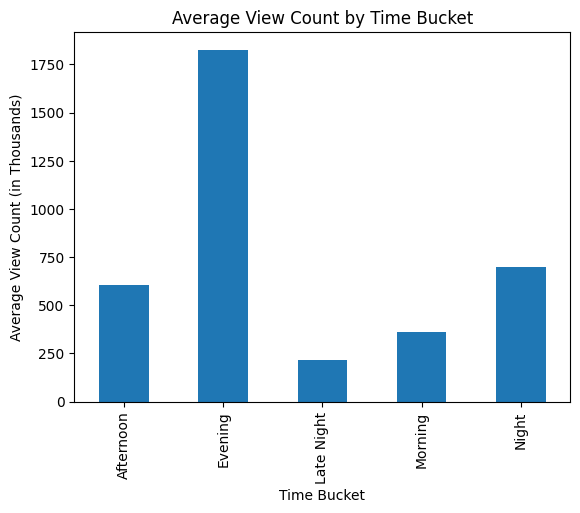

In [91]:
df["views_per_k"] = df["views_per_day"]/1000
df.groupby("time_bucket")["views_per_k"].mean().plot(kind='bar')
plt.title('Average View Count by Time Bucket')
plt.xlabel('Time Bucket')
plt.ylabel('Average View Count (in Thousands)')
plt.show()

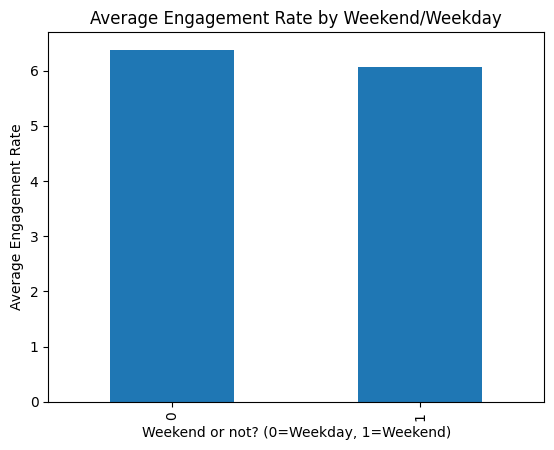

In [92]:
df.groupby("is_weekend")["engagement_rate"].mean().reindex([0,1]).plot(kind="bar")
plt.title('Average Engagement Rate by Weekend/Weekday')
plt.xlabel('Weekend or not? (0=Weekday, 1=Weekend)')
plt.ylabel('Average Engagement Rate')
plt.show()

In [93]:
df.groupby("is_weekend")["views_per_day"].mean().sort_values(ascending=False)


is_weekend
0    834574.217949
1    205995.272727
Name: views_per_day, dtype: float64

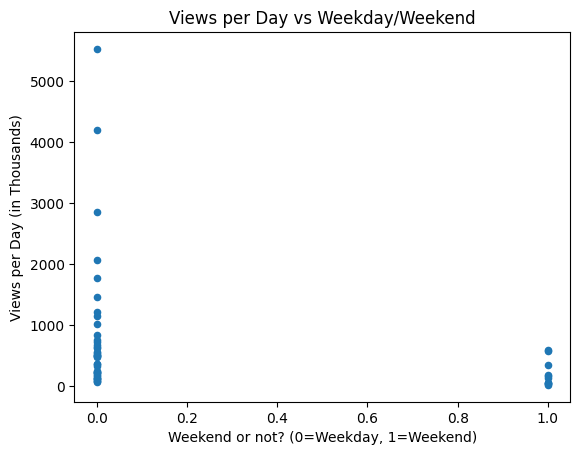

In [94]:
df.plot(kind='scatter',x='is_weekend',y='views_per_k')
plt.title('Views per Day vs Weekday/Weekend')
plt.xlabel('Weekend or not? (0=Weekday, 1=Weekend)')
plt.ylabel('Views per Day (in Thousands)')
plt.show()

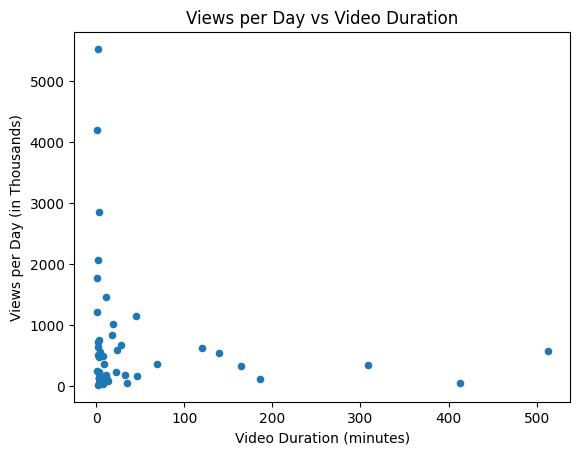

In [95]:
df.plot(kind='scatter',x='duration_parsed',y='views_per_k')
plt.title('Views per Day vs Video Duration')
plt.xlabel('Video Duration (minutes)')
plt.ylabel('Views per Day (in Thousands)')
plt.show()

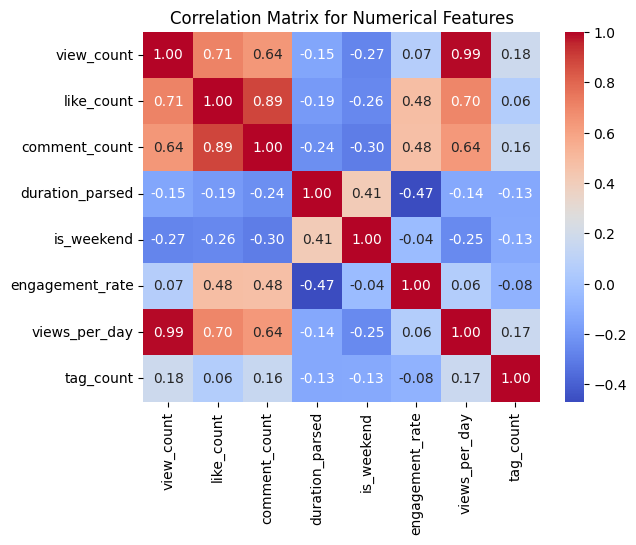

In [96]:
import seaborn as sns
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix for Numerical Features')
plt.show()

In [97]:
group = df.groupby("tag_count")["views_per_day"].mean().sort_values(ascending=False)
group_k = group / 1000
group_k = group_k.round(1).astype(str) + "K"
group_k.head(15)


tag_count
19    2410.5K
24    2248.8K
11    1607.3K
22    1462.7K
18    1340.5K
15    1212.0K
34     600.9K
21     587.4K
6      512.8K
4      507.6K
40     505.7K
25     491.1K
3      476.0K
1      451.8K
14     319.3K
Name: views_per_day, dtype: object

In [98]:
df.groupby("channel_title")["views_per_day"].mean().sort_values().head(15)
 

channel_title
Peysoh                   24957.0
Cartoon Universe         41609.0
DarkViperAU              53825.0
Screwly G                55395.0
YoThatsEJ                62288.0
AmaDiCi                  77246.0
SuperHorrorBro           81199.0
Digital Car Addict       89958.0
FusionZGamer            127502.0
Revive Music            128134.0
Baky Popile Official    132061.0
AerosmithVEVO           136886.0
LukeCombsVEVO           144483.0
Joe Bart Games          172276.0
Ayy Lmao                173127.0
Name: views_per_day, dtype: float64